NAME:SWATHI V 24BAD122

PERCEPTRON CLASS

In [ ]:
import numpy as np

class Perceptron:

    def __init__(self, num_inputs, learning_rate=0.01):
        self.weights = np.random.rand(num_inputs + 1)
        self.learning_rate = learning_rate

    # Linear Layer
    def linear(self, inputs):
        return np.dot(inputs, self.weights[1:]) + self.weights[0]

    # Activation Function
    def Heaviside_step_fn(self, z):
        if z >= 0:
            return 1
        else:
            return 0

    # Prediction
    def predict(self, inputs):

        z = self.linear(inputs)

        if np.ndim(z) == 0:
            return self.Heaviside_step_fn(z)

        predictions = []

        for value in z:
            predictions.append(self.Heaviside_step_fn(value))

        return predictions

    # Loss
    def loss(self, prediction, target):
        return target - prediction

    # Train
    def train(self, inputs, target):

        prediction = self.predict(inputs)

        error = self.loss(prediction, target)

        self.weights[1:] += self.learning_rate * error * inputs
        self.weights[0] += self.learning_rate * error

    # Fit
    def fit(self, X, y, num_epochs):

        for epoch in range(num_epochs):

            for inputs, target in zip(X, y):

                self.train(inputs, target)

AND & OR LOGIC -task1

In [ ]:
from sklearn.metrics import accuracy_score

# AND GATE

print("===== AND GATE =====")

X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

model = Perceptron(num_inputs=2, learning_rate=0.1)

model.fit(X_and, y_and, num_epochs=20)

predictions = []

for sample in X_and:
    predictions.append(model.predict(sample))

for x,p in zip(X_and,predictions):
    print(x,"->",p)

accuracy = accuracy_score(y_and,predictions)

print("AND Accuracy =",accuracy*100,"%")


# OR GATE

print("\n===== OR GATE =====")

X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

model = Perceptron(num_inputs=2, learning_rate=0.1)

model.fit(X_or,y_or,num_epochs=20)

predictions=[]

for sample in X_or:
    predictions.append(model.predict(sample))

for x,p in zip(X_or,predictions):
    print(x,"->",p)

accuracy = accuracy_score(y_or,predictions)

print("OR Accuracy =",accuracy*100,"%")

===== AND GATE =====
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1
AND Accuracy = 100.0 %

===== OR GATE =====
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1
OR Accuracy = 100.0 %


Kaggle Dataset (Diabetes)  -task2

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load Dataset
data = pd.read_csv("diabetes.csv")

print(data.head())

# Features and Target
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Create Model
model = Perceptron(num_inputs=X.shape[1], learning_rate=0.01)

# Train Model
model.fit(X, y, num_epochs=300)

# Prediction
predictions = []

for sample in X:
    predictions.append(model.predict(sample))

# Accuracy
accuracy = accuracy_score(y, predictions)

print("\nModel Accuracy:", accuracy * 100, "%")

print("\nSample Predictions:")

for i in range(10):
    print("Actual =", y[i], "Predicted =", predictions[i])

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Model Accuracy: 71.875 %

Sample Predictions:
Actual = 1 Predicted = 0
Actual = 0 Predicted = 0
Actual = 1 Predicted = 1
Actual = 0 Predicted = 0
Actual = 1 Predicted = 1
Actual = 0 Predicted = 0
Actual = 1 Predicted = 0
Actual = 0 Predicted = 0
Actual = 1 Predicted = 1
Actual = 1 Predicted = 0


Single-Layer Perceptron

Accuracy: 0.980


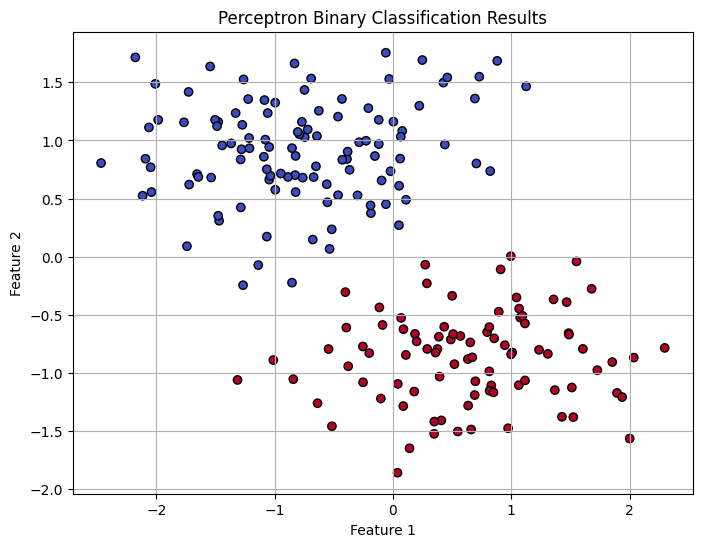

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define the Perceptron Class
class Perceptron:
    def __init__(self, num_inputs, learning_rate=0.01):
        # Initialize the weights (num_inputs + 1 for bias)
        self.weights = np.random.rand(num_inputs + 1)  # Random initialization
        self.learning_rate = learning_rate            # Learning rate

    def linear(self, inputs):
        # Weighted sum: XW + b
        Z = inputs @ self.weights[1:].T + self.weights[0]
        return Z

    def Heaviside_step_fn(self, z):
        # Activation function
        if z >= 0:
            return 1
        else:
            return 0

    def predict(self, inputs):
        Z = self.linear(inputs)
        try:
            pred = []
            for z in Z:  # For batch inputs
                pred.append(self.Heaviside_step_fn(z))
            return np.array(pred)
        except TypeError:
            return self.Heaviside_step_fn(Z)  # For single input

    def loss(self, prediction, target):
        # Error calculation
        return target - prediction  # Actual - Predicted error direction

    def train(self, inputs, target):
        prediction = self.predict(inputs)
        error = self.loss(prediction, target)
        # Update weights and bias using Perceptron learning rule
        self.weights[1:] += self.learning_rate * error * inputs
        self.weights[0] += self.learning_rate * error

    def fit(self, X, y, num_epochs):
        for epoch in range(num_epochs):
            for inputs, target in zip(X, y):
                self.train(inputs, target)


# 2. Data Preparation & Model Execution

# Generate synthetic linearly separable data
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=2,
    cluster_std=3,
    random_state=23
)

# Train-Test Split and Feature Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize & Train Perceptron
perceptron = Perceptron(num_inputs=X_train.shape[1])
perceptron.fit(X_train, y_train, num_epochs=100)

# Evaluate Performance
pred = perceptron.predict(X_test)
accuracy = np.mean(pred == y_test)
print(f"Accuracy: {accuracy:.3f}")

# Visualize Results
plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=pred, cmap='coolwarm', edgecolors='k')
plt.title("Perceptron Binary Classification Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

Single-Layer Perceptron with TensorFlow/Keras

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train Shape: (60000, 28, 28), Test Shape: (10000, 28, 28)


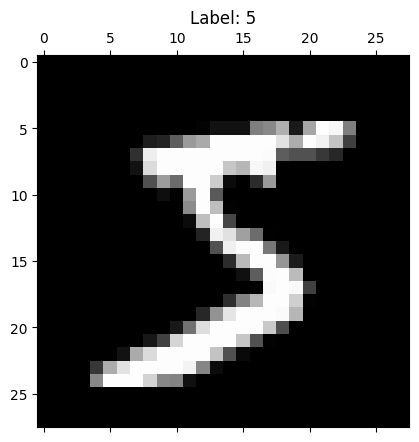

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8777 - loss: 0.4691
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9154 - loss: 0.3047
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9204 - loss: 0.2834
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9238 - loss: 0.2731
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9264 - loss: 0.2667
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9268 - loss: 0.2715

Test Loss: 0.2715, Test Accuracy: 0.9268


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# 1. Load Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Quick Visualization
print(f"Train Shape: {x_train.shape}, Test Shape: {x_test.shape}")
plt.matshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# 2. Normalize Pixel Values (0-255 -> 0.0-1.0)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Flatten 2D 28x28 images into 1D vectors of length 784
x_train_flatten = x_train.reshape(len(x_train), 28 * 28)
x_test_flatten = x_test.reshape(len(x_test), 28 * 28)

# 4. Build Single-Layer Architecture
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train Model
model.fit(x_train_flatten, y_train, epochs=5)

# 6. Evaluate Model
test_loss, test_acc = model.evaluate(x_test_flatten, y_test)
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Multi-Layer Perceptron (MLP) with TensorFlow/Keras

Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_train): (60000,)


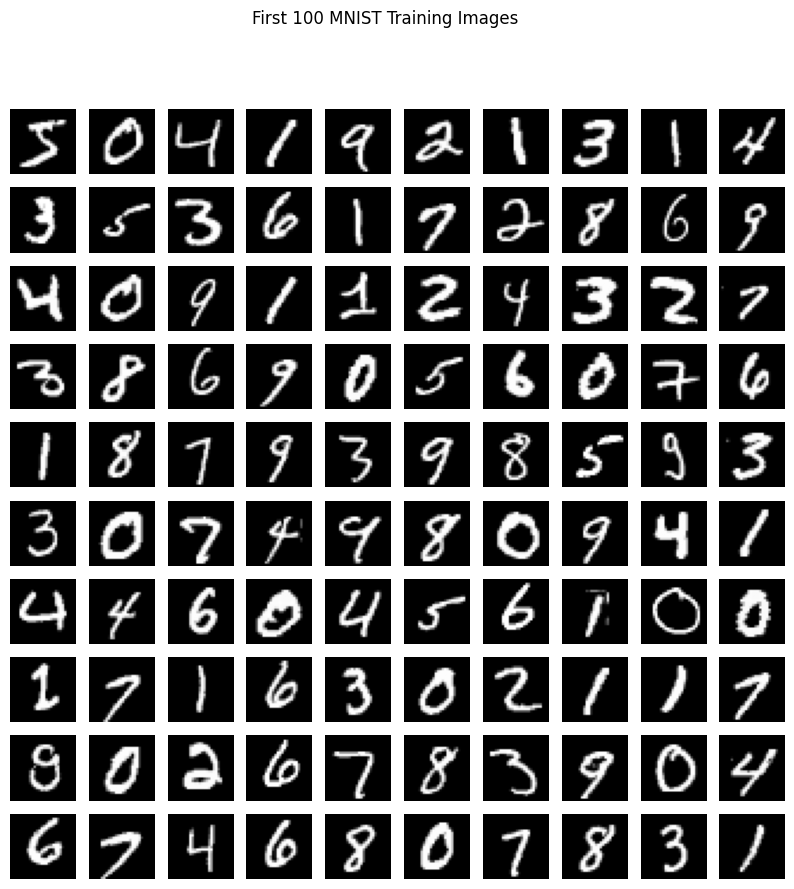

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.7305 - loss: 1.0527 - val_accuracy: 0.8923 - val_loss: 0.3695
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9061 - loss: 0.3241 - val_accuracy: 0.9252 - val_loss: 0.2569
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9309 - loss: 0.2432 - val_accuracy: 0.9402 - val_loss: 0.2078
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.9445 - loss: 0.1959 - val_accuracy: 0.9502 - val_loss: 0.1761
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.9528 - loss: 0.1635 - val_accuracy: 0.9553 - val_loss: 0.1541
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9601 - loss: 0.1391 - val_accuracy: 0.9601 - val_loss: 0.1403
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9654 - loss: 0.1200 - val_accuracy: 0.9632 - val_loss: 0.1270
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9712 - loss: 0.1028 - val_accuracy: 0.9645 - 

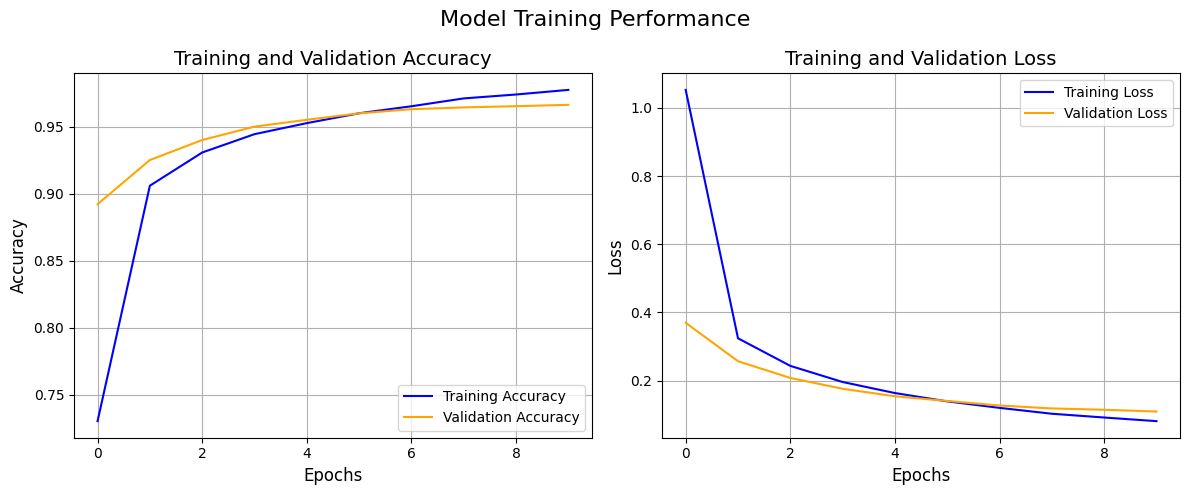

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# 1. Load & Normalize Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

gray_scale = 255.0
x_train = x_train.astype('float32') / gray_scale
x_test = x_test.astype('float32') / gray_scale

print("Feature matrix (x_train):", x_train.shape)
print("Target matrix (y_train):", y_train.shape)

# 2. Visualize Sample Grid (First 100 Samples)
fig, ax = plt.subplots(10, 10, figsize=(10, 10))
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k], cmap='gray', aspect='auto')
        ax[i][j].axis('off')
        k += 1
plt.suptitle("First 100 MNIST Training Images")
plt.show()

# 3. Build Multi-Layer Perceptron Network
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# 4. Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train Model
mod = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=2000,
    validation_split=0.2
)

# 6. Evaluate Test Performance
results = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest loss: {results[0]:.4f}, Test accuracy: {results[1]:.4f}")

# 7. Plot Training and Validation Performance Graphs
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()

McCulloch-Pitts Neuron (or Threshold Logic Unit)

In [ ]:
import numpy as np

def mcculloch_pitts_and(x1, x2):
    # Weights and threshold hardcoded for AND logic
    w1, w2 = 1, 1
    threshold = 2

    weighted_sum = x1 * w1 + x2 * w2
    return 1 if weighted_sum >= threshold else 0

# Test outputs
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(f"Input: {x} -> Output: {mcculloch_pitts_and(x[0], x[1])}")

Input: (0, 0) -> Output: 0
Input: (0, 1) -> Output: 0
Input: (1, 0) -> Output: 0
Input: (1, 1) -> Output: 1
